In [14]:
pip install google-play-scraper

In [15]:
from google_play_scraper import reviews, Sort
import csv

result, _ = reviews(
    'com.kai.kaiticketing',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=100,
    filter_score_with=None
)

filename = 'ulasan_google_play.csv'


In [16]:
with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
    writer.writeheader()
    for review in result:

        writer.writerow({
            'userName': review['userName'],
            'score': review['score'],
            'at': review['at'],
            'content': review['content']
        })

print(f"Berhasil menyimpan {len(result)} ulasan ke '{filename}'")

Berhasil menyimpan 100 ulasan ke 'ulasan_google_play.csv'


In [17]:
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv('ulasan_google_play.csv')

print("Data loaded successfully. Here are the first 5 rows:")
display(df.head())

Data loaded successfully. Here are the first 5 rows:


,userName,score,at,content
0,Taufik Bakransungkar,1,2026-05-05 14:05:50,makin kesini makin bego KAI....kalau kerja itu...
1,tono item,3,2026-05-05 13:57:37,"menu pemilihan kursi,kenapa jadi gak bis a pil..."
2,Hidayat Hidayat,1,2026-05-05 13:41:52,seharusnya kai acces jangan kebanyakan bisnis ...
3,Current Acc,3,2026-05-05 13:38:02,"min, aplikasinya untuk tiket masih ada yang bu..."
4,Hafidz Fajarudin,5,2026-05-05 13:26:11,kembalikan Booking hingga 10 Kursi Per Akun se...


In [18]:
pip install transformers

In [19]:
from transformers import pipeline

In [20]:
sentiment_pipeline = pipeline("sentiment-analysis", model="w11wo/indonesian-roberta-base-prdect-id")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-prdect-id
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [21]:
def get_sentiment(text):
    if pd.isna(text):
        return {'label': 'neutral', 'score': 0.0} # Handle NaN or empty content
    try:
        # The model returns a list of dictionaries, so we take the first one
        result = sentiment_pipeline(text)[0]
        return result
    except Exception as e:
        print(f"Error processing text: {text[:50]}... Error: {e}")
        return {'label': 'error', 'score': 0.0}

df['sentiment_analysis'] = df['content'].apply(get_sentiment)

In [22]:
df['sentiment_label'] = df['sentiment_analysis'].apply(lambda x: x['label'])
df['sentiment_score'] = df['sentiment_analysis'].apply(lambda x: x['score'])

print("Sentiment analysis complete. Here are the first 5 rows with new sentiment columns:")
display(df.head())

Sentiment analysis complete. Here are the first 5 rows with new sentiment columns:


,userName,score,at,content,sentiment_analysis,sentiment_label,sentiment_score
0,Taufik Bakransungkar,1,2026-05-05 14:05:50,makin kesini makin bego KAI....kalau kerja itu...,"{'label': 'Anger', 'score': 0.5096279978752136}",Anger,0.509628
1,tono item,3,2026-05-05 13:57:37,"menu pemilihan kursi,kenapa jadi gak bis a pil...","{'label': 'Fear', 'score': 0.4838685393333435}",Fear,0.483869
2,Hidayat Hidayat,1,2026-05-05 13:41:52,seharusnya kai acces jangan kebanyakan bisnis ...,"{'label': 'Fear', 'score': 0.5568262338638306}",Fear,0.556826
3,Current Acc,3,2026-05-05 13:38:02,"min, aplikasinya untuk tiket masih ada yang bu...","{'label': 'Fear', 'score': 0.5258312225341797}",Fear,0.525831
4,Hafidz Fajarudin,5,2026-05-05 13:26:11,kembalikan Booking hingga 10 Kursi Per Akun se...,"{'label': 'Fear', 'score': 0.4195547103881836}",Fear,0.419555


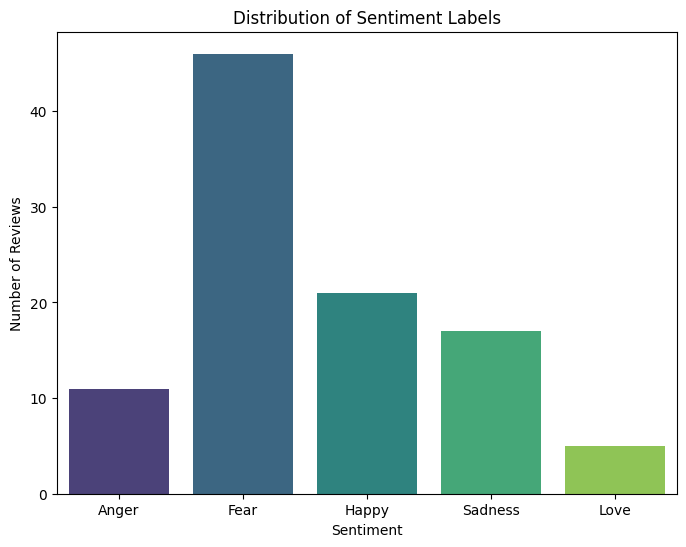

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment_label', data=df, hue='sentiment_label', palette='viridis', legend=False)
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()